# Walk Forward Validation Analysis and Model Selection
In this notebook, we explore the results of the walk-forward validation experiment, portfolio performances. Eventually, these are used to selected models that will be passed on to the testing stage on completely unseen data with no look ahead bias.

### Setup:

In [1]:
# All imports
import sys
from pathlib import Path

# Get the absolute path of the directory one level up
root_dir = Path.cwd().parent

# Add it to sys.path if it's not already there
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import os
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from src.evaluation.evaluator import Evaluator
from src.utils.io import load_path_config
from src.data_processing.loading import load_csv_files, ArtifactDataExtractor
from src.evaluation.selection import filter_models
from sklearn.decomposition import PCA
from src.utils.formatting import deserialize_np_dict
from src.utils.window import calc_current_idxs, get_date_index_col
from sklearn.preprocessing import StandardScaler
from src.visualization.plots import plot_windowed_comparison, plot_corr, plot_3d_pareto, plot_2d_pareto, plot_2d_pareto_diff_colrs
from src.evaluation.selection import high_corr_with_each_metric, pareto_dominance
from src.utils.constants import EQ_WT_NAME, SP500_NAME

from src.models.registry import TradModelLibrary, NNModelLibrary
from src.evaluation.metrics import MetricLibrary

import re

In [2]:
paths_config = load_path_config(os.path.join('../config', 'paths.json'))

# Convert str paths to Path
artifacts_paths = {}
for name, path in paths_config['artifacts'].items():
    dir_path = Path('../'+ path)
    artifacts_paths[name] = dir_path

TradModelLibrary.autodiscover('src.models')
# Registering all NN models to the library
NNModelLibrary.autodiscover('src.models') # MUST be executed for model registration

In [3]:

grid_mode = 'one_model'
model_name = None
loss_name = None # Change previous grid mode if needed

extractor = ArtifactDataExtractor(grid_mode, artifacts_paths)

if grid_mode == 'one_model':
    # Get all models from library
    all_models = []
    for cat in NNModelLibrary.list_categories():
        all_models.extend(NNModelLibrary.list_models(cat))

    all_avg_perf = extractor.agg_avg_perf('avg_perf', all_models)
    opti_hparams = extractor.agg_opti_hparams('optimized', all_models)
    all_daily_rets = extractor.agg_daily_rets('daily_rets', all_models)
    
elif grid_mode == 'one' and model_name is not None and loss_name is not None:
    opti_hparams = extractor.agg_opti_hparams(
        'optimized', [f'{model_name}-{loss_name}']
    )
    filtered_models = None

#### Removing custom losses 13 and 14
This is done because there was a bug in the loss functions of 13 and 14 and rerunning would be very expensive. Will be fixed soon

In [4]:
mask = all_avg_perf.index.str.contains('-custom_loss_13|-custom_loss_14')
all_avg_perf = all_avg_perf[~mask]

pattern = re.compile(r'custom_loss_(13|14)')
opti_hparams = {k: v for k, v in opti_hparams.items() if not pattern.search(k)}

all_daily_rets = {k: v for k, v in all_daily_rets.items() if not pattern.search(k)}

#### Average Portfolio Performances
This is the average of portfolio metrics over all windows of walk steps. It is not the performances of the models over the entire validation period of 2 years.

In [5]:
# all_benches = TradModelLibrary.list_models()
all_benches = [EQ_WT_NAME, SP500_NAME]

# Filter models that beat Equal Weight Portfolio
filtered_perf, filtered_models = filter_models(
    all_avg_perf, EQ_WT_NAME, 'sharpe', all_benches
)

print(f'\n {len(filtered_models)} Models beat Equal Weight portfolio.')
# print('Filtered Avg. Performance Metrics: \n', filtered_perf)
filtered_perf = filtered_perf.sort_values(by='sharpe', ascending=False)
filtered_perf


 4 Models beat Equal Weight portfolio.


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
TemporalTransformer-custom_loss_11,0.116925,0.136675,0.213725,-0.107150,-0.038087,1.477050,0.031200
AttentionLSTM-custom_loss_11,0.086675,0.119913,0.198362,-0.094225,-0.033962,1.414625,0.030087
BaseLSTM-custom_loss_11,0.070775,0.109987,0.165675,-0.101325,-0.035300,1.375188,0.022100
VLSTM-custom_loss_11,0.100300,0.107900,0.190312,-0.130987,-0.039900,1.356600,0.025837
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575
S&P500,0.049075,0.104487,0.139950,-0.092262,-0.032350,1.343400,0.020125


In [6]:
all_avg_perf

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
DeformTime-custom_loss_10,0.044362,0.080825,0.126800,-0.120688,-0.039663,1.275038,0.020375
DeformTime-custom_loss_11,0.121750,0.105137,0.216938,-0.187150,-0.059487,1.466938,0.032500
Equal_Weight,0.056287,0.107725,0.163887,-0.095925,-0.031587,1.374600,0.022575
S&P500,0.049075,0.104487,0.139950,-0.092262,-0.032350,1.343400,0.020125
TemporalTransformer-custom_loss_10,0.056900,0.102112,0.158887,-0.096875,-0.032975,1.348688,0.021862
TemporalTransformer-custom_loss_11,0.116925,0.136675,0.213725,-0.107150,-0.038087,1.477050,0.031200
PatchTST-custom_loss_10,0.077525,0.086775,0.144450,-0.140662,-0.043950,1.273000,0.015550
PatchTST-custom_loss_11,0.073175,0.101712,0.173038,-0.110225,-0.034537,1.312700,0.021087
BaseLSTM-custom_loss_10,0.076537,0.084200,0.141825,-0.123450,-0.040675,1.293063,0.020312
BaseLSTM-custom_loss_11,0.070775,0.109987,0.165675,-0.101325,-0.035300,1.375188,0.022100


### Mean Sharpe Analysis - Overall View

Models/Approaches that BEAT Equal Weight Mean Sharpe:


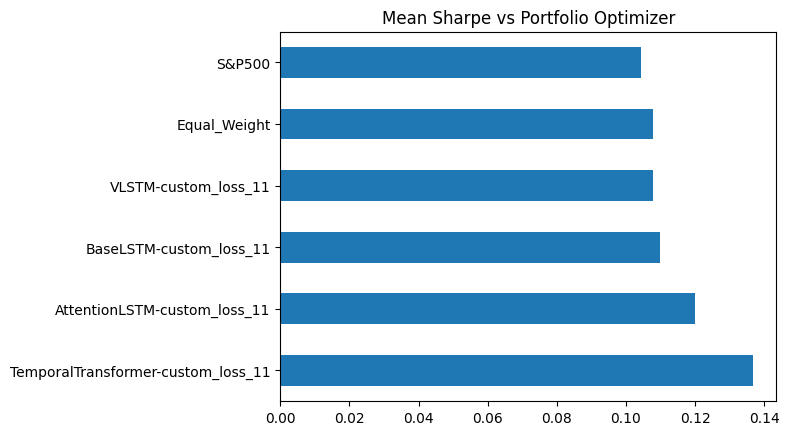

In [7]:
filtered_perf['sharpe'].plot.barh(title='Mean Sharpe vs Portfolio Optimizer')
print('Models/Approaches that BEAT Equal Weight Mean Sharpe:')

In [8]:
print('Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:')
no_beat = all_avg_perf.drop(filtered_perf.index, axis=0)
print(f'{len(no_beat)} NN models did not beat Equal Weight Portfolio:')
no_beat

Models/Approaches that DID NOT BEAT Equal Weight Mean Sharpe:
10 NN models did not beat Equal Weight Portfolio:


,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
DeformTime-custom_loss_10,0.044362,0.080825,0.126800,-0.120688,-0.039663,1.275038,0.020375
DeformTime-custom_loss_11,0.121750,0.105137,0.216938,-0.187150,-0.059487,1.466938,0.032500
TemporalTransformer-custom_loss_10,0.056900,0.102112,0.158887,-0.096875,-0.032975,1.348688,0.021862
PatchTST-custom_loss_10,0.077525,0.086775,0.144450,-0.140662,-0.043950,1.273000,0.015550
PatchTST-custom_loss_11,0.073175,0.101712,0.173038,-0.110225,-0.034537,1.312700,0.021087
BaseLSTM-custom_loss_10,0.076537,0.084200,0.141825,-0.123450,-0.040675,1.293063,0.020312
AttentionLSTM-custom_loss_10,0.076700,0.057337,0.119762,-0.186462,-0.057812,1.215438,0.015350
InvertedAttentionLSTM-custom_loss_10,0.053525,0.091987,0.138263,-0.102913,-0.032037,1.287600,0.016675
InvertedAttentionLSTM-custom_loss_11,0.088938,0.071087,0.141837,-0.189350,-0.060275,1.372150,0.026862
VLSTM-custom_loss_10,0.034125,0.031363,0.069562,-0.174662,-0.050638,1.130750,0.010562


#### Models Portfolio Performances
This is the performance of each portfolio for the entire validation period

In [9]:
metrics_to_ann = ['sharpe', 'sortino', 'calmar']

evaluator = Evaluator(
    eval_returns=None,
    ba_eval=None,
    all_daily_returns=deserialize_np_dict(all_daily_rets), # Deserialize dict: replace lists with np.array()
    metrics_lib=MetricLibrary.items()
)

all_overall_perfs = evaluator.calc_pf_performances(metrics_to_ann)

all_overall_perfs['compunded_return'] = all_overall_perfs['compunded_return']*100
all_overall_perfs['max_drawdown'] = all_overall_perfs['max_drawdown']*100
all_overall_perfs['cvar'] = all_overall_perfs['cvar']*100

all_overall_perfs = all_overall_perfs.sort_values(by='sharpe', ascending=False)
all_overall_perfs

,compunded_return,sharpe,sortino,max_drawdown,cvar,omega,calmar
TemporalTransformer-custom_loss_11,128.95,1.5572,1.9081,-33.20,-4.49,1.3401,1.6410
VLSTM-custom_loss_11,102.92,1.2748,1.7268,-40.01,-4.63,1.2522,1.1245
AttentionLSTM-custom_loss_11,87.16,1.2725,1.5646,-35.04,-4.25,1.2829,1.1122
PatchTST-custom_loss_11,73.65,1.1240,1.4759,-34.88,-4.19,1.2321,0.9635
BaseLSTM-custom_loss_11,67.31,1.0916,1.2949,-34.99,-4.39,1.2400,0.8867
DeformTime-custom_loss_11,113.52,1.0607,1.3956,-54.69,-6.93,1.2174,0.8946
BaseLSTM-custom_loss_10,72.20,1.0529,1.3904,-30.42,-4.55,1.2167,1.0854
PatchTST-custom_loss_10,76.23,1.0405,1.2898,-39.93,-5.06,1.2049,0.8675
InvertedAttentionLSTM-custom_loss_10,49.67,0.9550,1.1294,-34.67,-3.93,1.2031,0.6802
TemporalTransformer-custom_loss_10,49.72,0.9061,1.0525,-35.92,-4.31,1.1992,0.6571


#### Fixing Spelling Errors
compunded_returns -> comp_returns

max_drawdown -> mdd

In [10]:
all_overall_perfs = all_overall_perfs.rename(columns={"compunded_return": "comp_return", "max_drawdown": "mdd"})

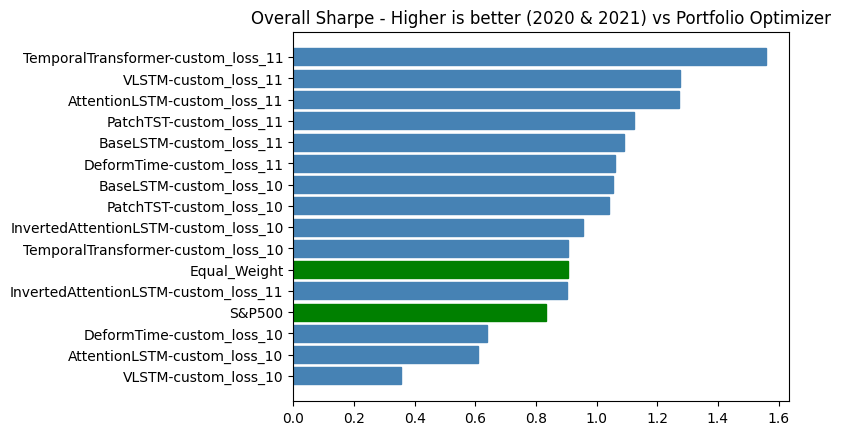

In [11]:
# all_overall_perfs['sharpe'].plot.barh(
#     title='Overall Sharpe (2020 & 2021) vs Portfolio Optimizer', color={'Equal_Weight': 'green', 'S&P500': 'green'}
# )
 
temp_perfs = all_overall_perfs.sort_values(by='sharpe', ascending=True)
fig, ax = plt.subplots()
bars = ax.barh(temp_perfs.index, temp_perfs['sharpe'])
for bar, idx in zip(bars, temp_perfs.index):
    if idx in ['Equal_Weight', 'S&P500']:
        bar.set_color('green')
    else:
        bar.set_color('steelblue')
ax.set_title('Overall Sharpe - Higher is better (2020 & 2021) vs Portfolio Optimizer')
plt.show()

In [12]:
# Split Benchmarks and filtered models
benchmarks_df = all_overall_perfs[all_overall_perfs.index.isin(all_benches)]
all_overall_perfs = all_overall_perfs[~all_overall_perfs.index.isin(all_benches)]

##### *NOTE:* From here onwards we use the dataframe consisting of overall portfolio performances over 2 years and not the average performances over all windows.

## Multi Metric Analysis:

### Correlation Analysis

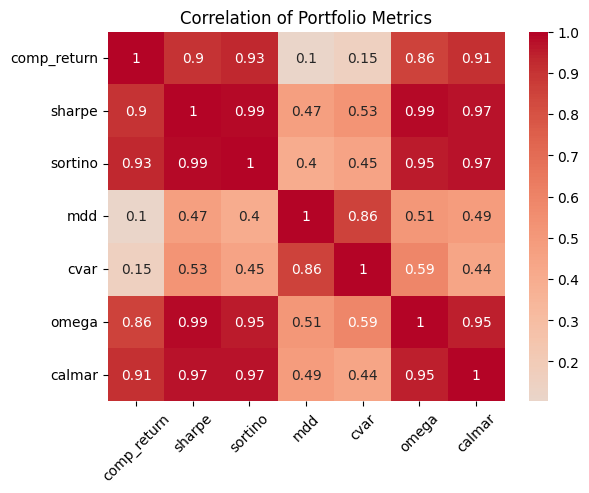


comp_return is highly correlated with:
  sharpe: 0.901
  sortino: 0.929
  omega: 0.855
  calmar: 0.910

sharpe is highly correlated with:
  comp_return: 0.901
  sortino: 0.985
  omega: 0.987
  calmar: 0.972

sortino is highly correlated with:
  comp_return: 0.929
  sharpe: 0.985
  omega: 0.954
  calmar: 0.970

mdd is highly correlated with:
  cvar: 0.856

cvar is highly correlated with:
  mdd: 0.856

omega is highly correlated with:
  comp_return: 0.855
  sharpe: 0.987
  sortino: 0.954
  calmar: 0.949

calmar is highly correlated with:
  comp_return: 0.910
  sharpe: 0.972
  sortino: 0.970
  omega: 0.949


In [13]:
corr = all_overall_perfs.corr()

plot_corr(corr, title='Correlation of Portfolio Metrics')

high_corr_with_each_metric(corr, threshold=0.75)

Most metrics are highly correlated with each other, with omega and sharpe showing high correlation with most of the other metrics. We can choose Sharpe, Calmar and maybe even CVaR to be our main metrics. CVaR and MDD are highly correlated so we can have one of them to add in loss like or bad scenarios.

##### Principle Component Analysis:

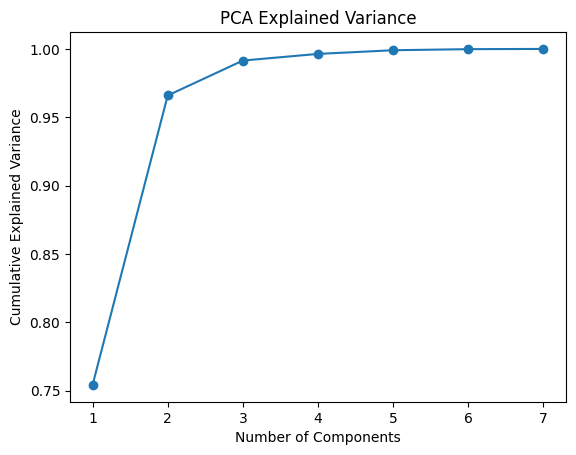

In [14]:
scaler = StandardScaler()
scaled_perf = scaler.fit_transform(all_overall_perfs)

pca = PCA()
pca.fit(scaled_perf)

# Explained variance ratio
explained = pca.explained_variance_ratio_
cumulative = explained.cumsum()

plt.plot(range(1, len(explained)+1), cumulative, 'o-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

The first principle component explains ~ 25% of the variance. At 6 princple components, almost 100% of the variance is explained.

In [15]:
loadings = pca.components_.T 

def print_important_metrics(loadings, metrics, n_components=5, top_n=3):
    for i in range(n_components):
        # Get loadings for component i
        comp_loadings = loadings[:, i]
        # Sort by absolute value
        sorted_idx = np.argsort(np.abs(comp_loadings))[::-1]
        print(f"\nPrincipal Component {i+1} (explained variance: {pca.explained_variance_ratio_[i]:.3f})")
        for j in range(top_n):
            idx = sorted_idx[j]
            print(f"  {metrics[idx]}: {comp_loadings[idx]:.3f}")

# Example:
print_important_metrics(loadings, all_overall_perfs.columns, n_components=6, top_n=3)


Principal Component 1 (explained variance: 0.754)
  sharpe: 0.431
  omega: 0.429
  calmar: 0.424

Principal Component 2 (explained variance: 0.212)
  mdd: 0.637
  cvar: 0.615
  comp_return: -0.411

Principal Component 3 (explained variance: 0.026)
  mdd: 0.637
  cvar: -0.618
  calmar: 0.385

Principal Component 4 (explained variance: 0.005)
  omega: 0.753
  sortino: -0.514
  cvar: -0.269

Principal Component 5 (explained variance: 0.003)
  comp_return: 0.652
  sortino: -0.630
  sharpe: -0.262

Principal Component 6 (explained variance: 0.001)
  calmar: 0.657
  sharpe: -0.561
  comp_return: -0.340


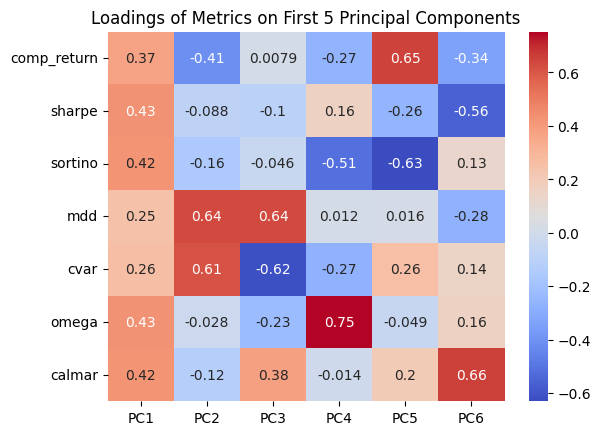

In [16]:
plt.figure()
sns.heatmap(loadings[:, :6], annot=True, cmap='coolwarm', 
            xticklabels=[f'PC{i+1}' for i in range(6)],
            yticklabels=all_overall_perfs.columns)
plt.title('Loadings of Metrics on First 5 Principal Components')
plt.savefig('./pc_val_loadings.png', dpi=300, bbox_inches='tight')
plt.show()

PC1 (explains 50.0% of variance) – High positive loadings on Sharpe (0.50), Omega (0.48), and Sortino (0.48).
- PC1 captures risk‑adjusted return (higher is better).
PC2 (explains 27.8% of variance) – High positive loading on CVaR (0.58) (which is undesirable) and negative loadings on Calmar (–0.46) and compounded return (–0.46) (both desirable).
- Higher PC2 indicates higher tail risk, lower drawdown‑adjusted return, and lower raw return – i.e., worse overall.
- To align with “higher is better”, we invert PC2 (use –PC2). Then –PC2 represents low tail risk, high Calmar, and high raw return.
PC3 (explains 12.9% of variance) – High positive loading on compounded return (0.76) but also positive on CVaR (0.33) and negative on Calmar (–0.48). This component is ambiguous (higher raw return comes with higher tail risk and lower Calmar), so we do not use it for Pareto selection.
Thus, we construct a 2D Pareto frontier using PC1 (risk‑adjusted return) and –PC2 (low tail risk + high Calmar/return). Both dimensions are “higher is better”, providing a clear, interpretable trade‑off. This approach leverages the PCA results while avoiding the complexity of a third dimension.

For robustness, we also consider the original metrics Sharpe (primary), Calmar (drawdown control), and CVaR (tail risk) as a sanity check. However, the PC1 + –PC2 combination already captures the same information in a more balanced way.

##### Pareto Frontier with Top 2 Principle Components

In [17]:
# Transform the standardized data (already filtered to models only, no benchmarks)
pca_scores = pca.transform(scaled_perf)   # shape (n_models, n_components)

pc_df = pd.DataFrame({
    'PC1': pca_scores[:, 0],
    'PC2_inv': -pca_scores[:, 1]          # invert so higher is better
}, index=all_overall_perfs.index)

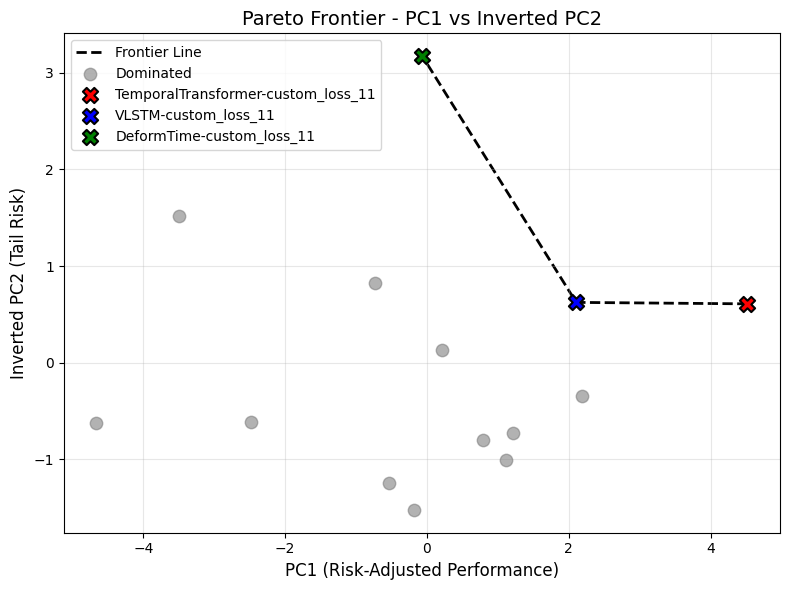

,PC1,PC2_inv,dominated
DeformTime-custom_loss_11,-0.064948,3.172444,False
VLSTM-custom_loss_11,2.106325,0.624358,False
TemporalTransformer-custom_loss_11,4.520918,0.609376,False


In [18]:
pc_df['dominated'] = pareto_dominance(pc_df, ['PC1', 'PC2_inv'])
frontier = pc_df[~pc_df['dominated']].copy()

frontier_sorted = frontier.sort_values('PC1')

plot_2d_pareto_diff_colrs(
    df=pc_df,
    x_col='PC1',
    y_col='PC2_inv',
    dominated_col='dominated',
    title='Pareto Frontier - PC1 vs Inverted PC2',
    xlabel='PC1 (Risk-Adjusted Performance)',
    ylabel='Inverted PC2 (Tail Risk)',
    colormap=['red','blue','green'],
    line_color='black',
    output_path='pc_val_pareto.png'
)

plt.show()
frontier_sorted

##### Pareto Frontier with 2 or 3 Metrics

In [19]:
fig = px.scatter_3d(
    all_overall_perfs,
    x='sharpe',
    y='comp_return',
    z='cvar',
    hover_name=all_overall_perfs.index,
    color='sharpe',                # color by Sharpe (or any metric)
    title='3D Performances Plot: Sharpe, Calmar, CVaR',
    labels={
        'sharpe': 'Sharpe Ratio',
        'compunded_return': 'Compounded Return',
        'cvar': 'CVaR (higher better)'
    }
)

# Update marker size and appearance
fig.update_traces(marker=dict(size=5, line=dict(width=1, color='DarkSlateGrey')))

fig.show()

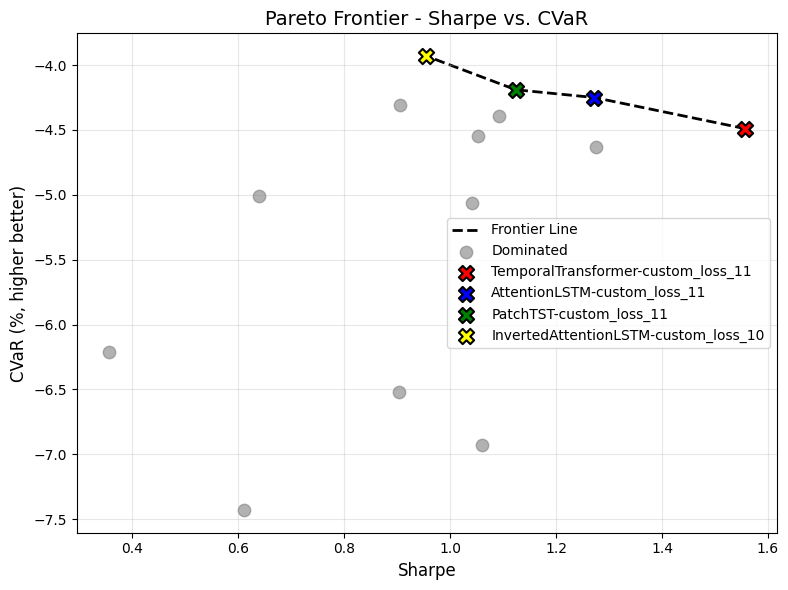

,comp_return,sharpe,sortino,mdd,cvar,omega,calmar,dominated
TemporalTransformer-custom_loss_11,128.95,1.5572,1.9081,-33.20,-4.49,1.3401,1.6410,False
AttentionLSTM-custom_loss_11,87.16,1.2725,1.5646,-35.04,-4.25,1.2829,1.1122,False
PatchTST-custom_loss_11,73.65,1.1240,1.4759,-34.88,-4.19,1.2321,0.9635,False
InvertedAttentionLSTM-custom_loss_10,49.67,0.9550,1.1294,-34.67,-3.93,1.2031,0.6802,False


In [20]:
temp_perf = all_overall_perfs.copy()

temp_perf['dominated'] = pareto_dominance(temp_perf, ['sharpe', 'cvar'])

frontier_2d = temp_perf[~temp_perf['dominated']]

plot_2d_pareto_diff_colrs(
    df=temp_perf,
    x_col='sharpe',
    y_col='cvar',
    dominated_col='dominated',
    title='Pareto Frontier - Sharpe vs. CVaR',
    xlabel='Sharpe',
    ylabel='CVaR (%, higher better)',
    colormap=['red','blue','green', 'yellow'],
    line_color='black',
    output_path='val_pareto.png'
)

plt.show()
frontier_sorted = frontier_2d.sort_values('sharpe', ascending=False)
frontier_sorted

In [21]:
temp_perf = all_overall_perfs.copy()

cols = ['sharpe', 'comp_return', 'cvar']
temp_perf['dominated_3d'] = pareto_dominance(temp_perf, cols)

frontier_3d = temp_perf[~temp_perf['dominated_3d']]

fig = plot_3d_pareto(
    df=temp_perf,
    x_col='sharpe',
    y_col='comp_return',
    z_col='cvar',
    dominated_col='dominated_3d',
    title='3D Pareto Frontier - Sharpe, Compounded Return, CVaR',
    x_title='Sharpe Ratio',
    y_title='Compounded Return',
    z_title='CVaR (higher better)'
)

fig.show()

# Efficient frontier models vs Benchmarks
frontier_model_names = list(frontier_3d.index)
pd.concat(
    [frontier_3d.sort_values(by='sharpe', ascending=False), benchmarks_df],
    axis=0
)

,comp_return,sharpe,sortino,mdd,cvar,omega,calmar,dominated_3d
TemporalTransformer-custom_loss_11,128.95,1.5572,1.9081,-33.20,-4.49,1.3401,1.6410,False
AttentionLSTM-custom_loss_11,87.16,1.2725,1.5646,-35.04,-4.25,1.2829,1.1122,False
PatchTST-custom_loss_11,73.65,1.1240,1.4759,-34.88,-4.19,1.2321,0.9635,False
InvertedAttentionLSTM-custom_loss_10,49.67,0.9550,1.1294,-34.67,-3.93,1.2031,0.6802,False
Equal_Weight,48.90,0.9059,1.0343,-35.85,-4.23,1.2045,0.6484,NaN
S&P500,42.45,0.8341,0.9324,-33.93,-4.28,1.1902,0.6017,NaN


#### Daily Returns for the frontier models

In [22]:
processed_files = {
    'returns_val': Path(paths_config['processed_paths']['returns_val'])
}

processed_dfs = load_csv_files(processed_files, index_dt=True)

def extract_window_dates(returns_val, num_steps, out_size):
    out_wind_idxs = []
    for step in range(1, num_steps+1):
        current_start, current_end = calc_current_idxs(step, out_size)

        out_wind_idxs.append((current_start, current_end))
    
    out_win_date_cols = get_date_index_col(returns_val, out_wind_idxs)

    return out_win_date_cols


out_win_date_cols = extract_window_dates(processed_dfs['returns_val'], 8, 60)

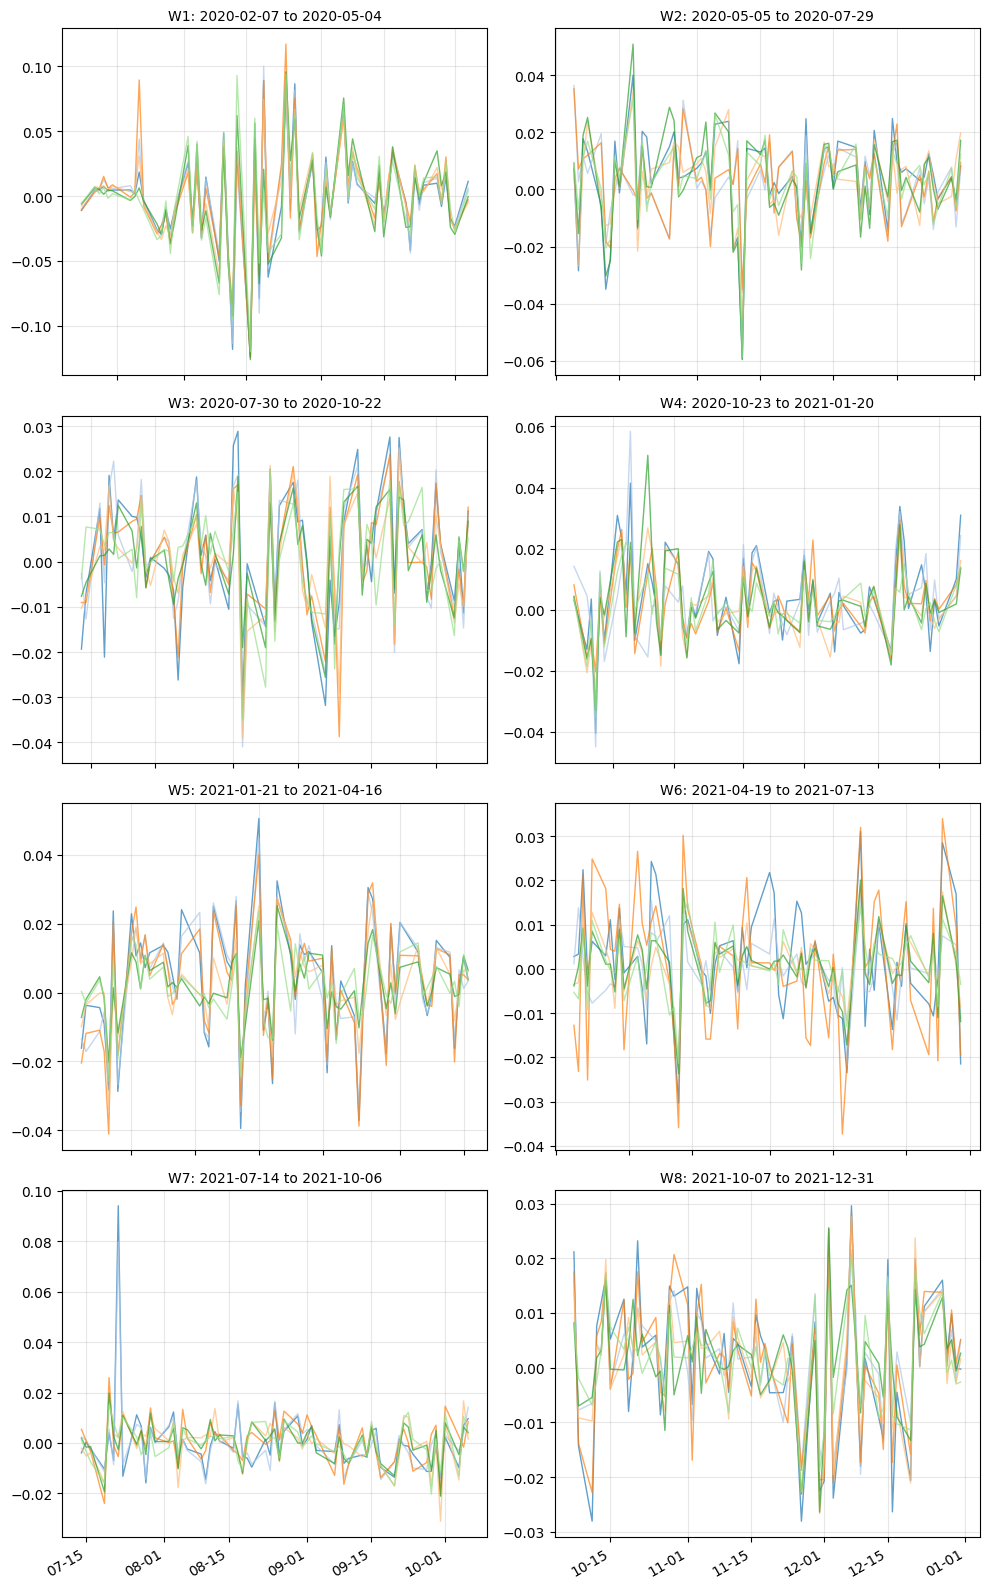

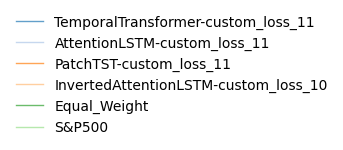

In [23]:
if all_daily_rets:    
    frontier_daily_rets = {
        k: all_daily_rets[k] for k in frontier_model_names if k in frontier_model_names
    }

    for bench in all_benches:
        bench_rets = all_daily_rets.get(bench)
        if bench_rets:
            frontier_daily_rets.update({bench: bench_rets})

    plot_windowed_comparison(
        all_daily_returns=frontier_daily_rets,
        window_dates=out_win_date_cols,
        windows_per_row=2,
        plot=True
    )
else:
    print('WARNING: No daily returns found.')

#### Training Loss Curves for best performing model loss combination

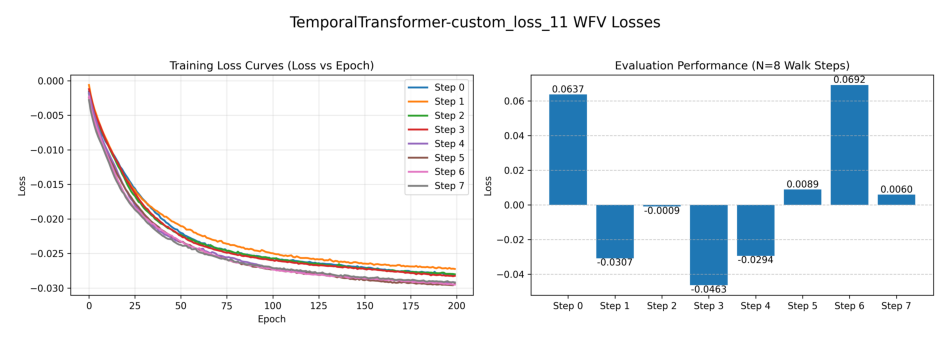

{'model': {'hidden_size': 32,
  'lstm_layers': 1,
  'trans_layers': 1,
  'nheads': 2,
  'dropout': 0.10960857653576966,
  'expansion_factor': 4,
  'equal_prior': False},
 'optimizer': {'lr': 0.00010892235722629424,
  'weight_decay': 0.011286148334326314},
 'train': {'train_batch_size': 64,
  'val_batch_size': 64,
  'clip_grad_norm': 0.5,
  'epochs': 200,
  'min_epochs': 0,
  'early_stopping': False,
  'early_stop_patience': 20,
  'early_stop_min_delta': 0.0001},
 'scheduler': {'factor': 0.5, 'patience': 10, 'min_lr': 1e-08},
 'loss': {'cvar_lambda': 0.001, 'risk_p_lambda': 0.1}}

In [24]:
def plot_train_curves(model_name):
    plt.figure(figsize=(12, 8))
    img = mpimg.imread(artifacts_paths['tuned_plots_dir'] / f'{model_name} WFV Losses.png')
    plt.imshow(img)
    plt.axis('off')  # hide axes
    plt.show()

model_name = 'TemporalTransformer-custom_loss_11'
plot_train_curves(model_name)
opti_hparams.get(model_name)

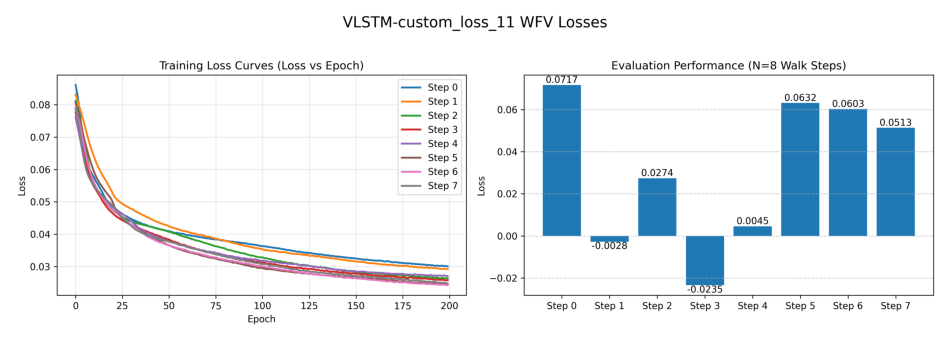

In [25]:
model_name = 'VLSTM-custom_loss_11'
plot_train_curves(model_name)

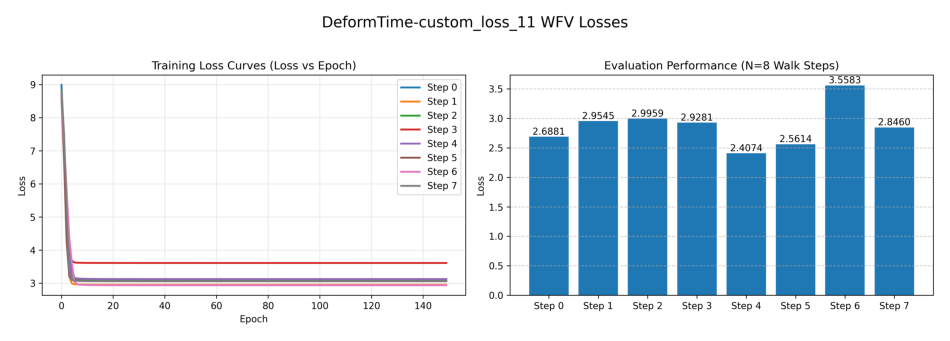

In [26]:
model_name = 'DeformTime-custom_loss_11'
plot_train_curves(model_name)

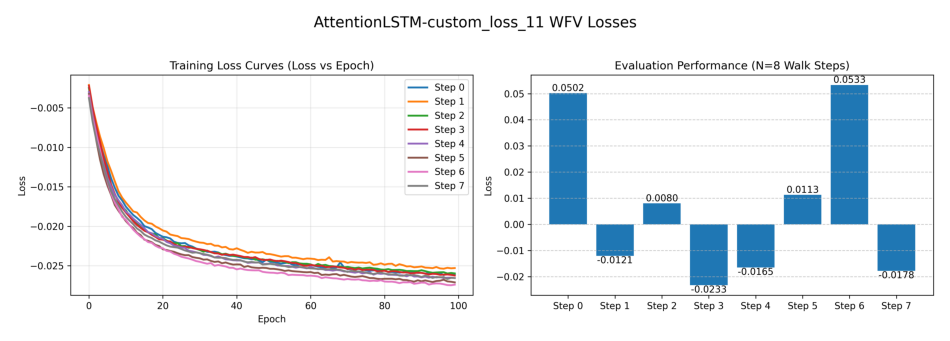

In [27]:
model_name = 'AttentionLSTM-custom_loss_11'
plot_train_curves(model_name)

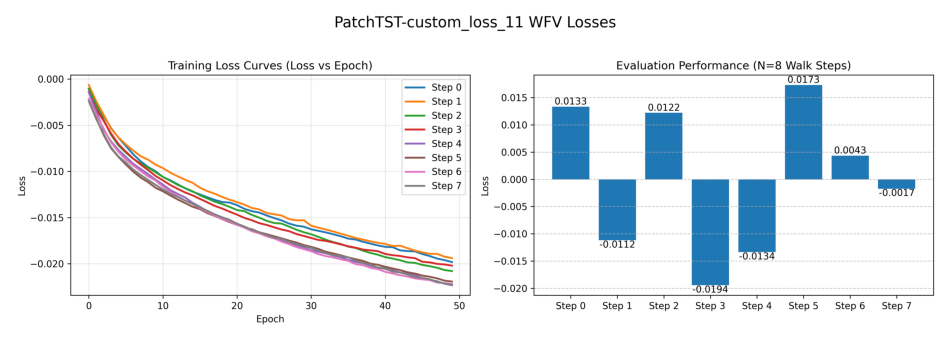

In [28]:
model_name = 'PatchTST-custom_loss_11'
plot_train_curves(model_name)

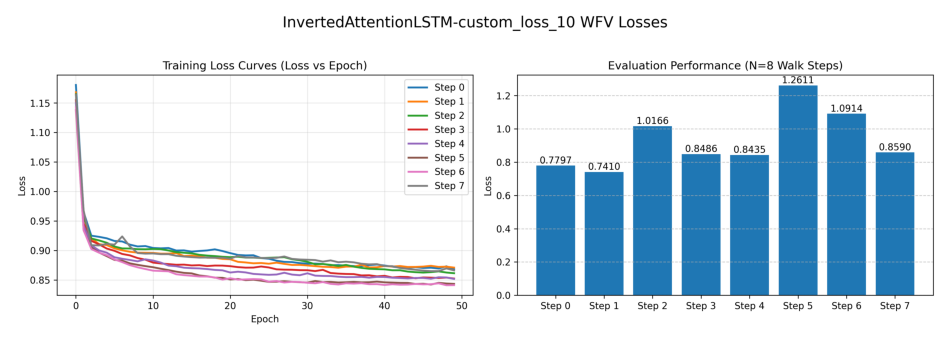

In [29]:
model_name = 'InvertedAttentionLSTM-custom_loss_10'
plot_train_curves(model_name)